market_price length: 1999
close_df shape: (1999, 28)
value_df shape: (1999, 28)


Backtest:  16%|█▋        | 287/1742 [00:22<01:27, 16.56it/s]Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows 


================ 백테스트 결과 ================

Total Return     2.253610
Annual Return    0.186095
Annual Vol       0.266447
Sharpe           0.773469
Sortino          1.192826
Max Drawdown    -0.510330
Avg Turnover     0.076000
Avg Exposure     0.937729
dtype: float64


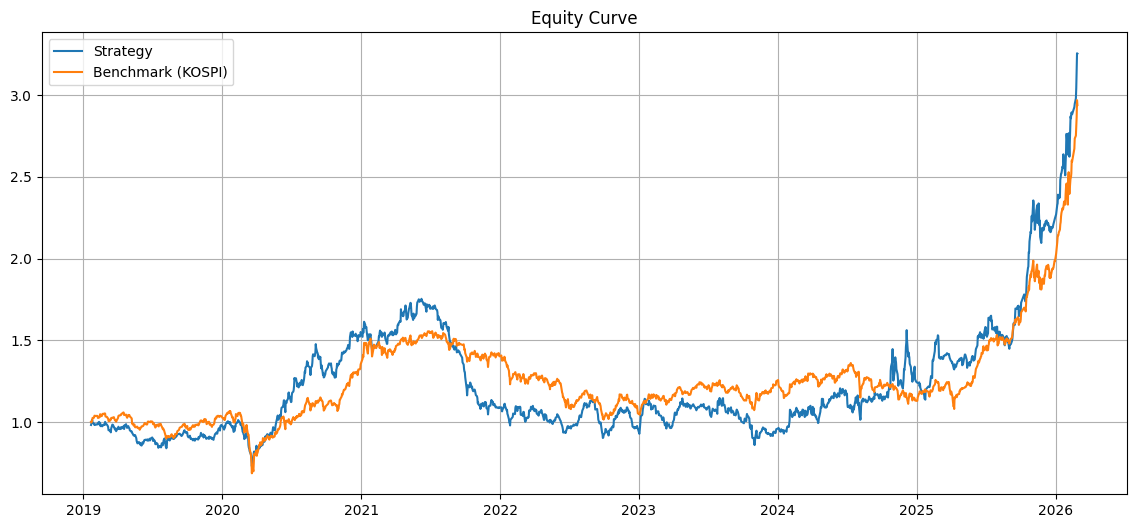

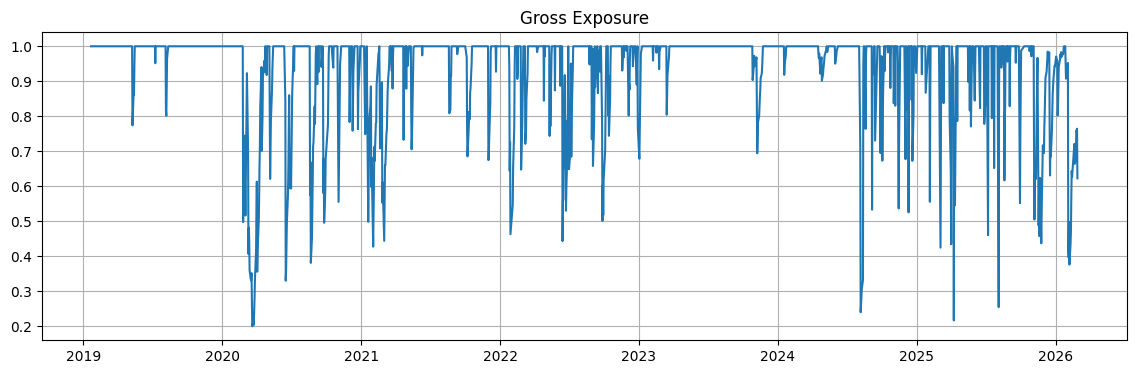

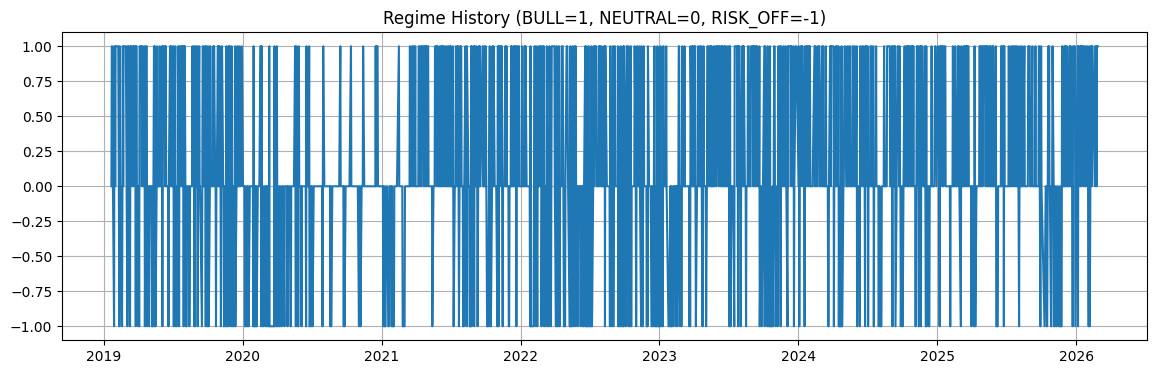


마지막 리밸런싱/보유 가중치
2026-02-27 00:00:00
{'005930.KS': 0.25477508599118726, '000270.KS': 0.25477508599118726, '207940.KS': 0.25477508599118726}


In [ ]:
# =========================================================
# HMM + GJR-GARCH Regime-Based Portfolio Backtest
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
from arch import arch_model

import yfinance as yf


# =========================================================
# 1) 설정값
# =========================================================

@dataclass
class Config:
    start_date: str = "2018-01-01"
    end_date: str = "2026-03-01"

    # 시장 프록시
    market_ticker: str = "^KS11"   # KOSPI 지수

    # 리밸런싱 주기(일)
    rebalance_freq: int = 20

    # 롤링 윈도우
    hmm_window: int = 252
    garch_window: int = 252
    sector_score_window: int = 60
    corr_window: int = 60

    # HMM
    n_states: int = 3
    hmm_covariance_type: str = "full"
    hmm_n_iter: int = 200
    random_state: int = 42

    # GJR-GARCH
    garch_p: int = 1
    garch_o: int = 1
    garch_q: int = 1

    # 포트폴리오
    top_n_sectors: int = 2
    max_assets: int = 4

    # 변동성 타이밍
    vol_target_annual: float = 0.18
    min_gross_exposure: float = 0.20
    max_gross_exposure: float = 1.00

    # 종목 선택
    min_history_ratio: float = 0.8
    min_liquidity_rank_ratio: float = 0.7   # 거래대금 상위 필터
    hedge_pick_from_top_k: int = 5

    # 거래비용
    fee_rate: float = 0.001   # 왕복 말고 리밸런싱 turnover 기준 단순 반영


cfg = Config()


# =========================================================
# 2) 유니버스 정의
#    예시: 한국 대표 종목을 섹터별로 묶음
#    필요하면 본인 유니버스로 바꾸시면 됩니다.
# =========================================================

SECTOR_UNIVERSE: Dict[str, List[str]] = {
    "반도체": ["005930.KS", "000660.KS"],
    "자동차": ["005380.KS", "000270.KS", "012330.KS"],
    "배터리": ["373220.KS", "006400.KS", "051910.KS"],
    "인터넷": ["035420.KS", "035720.KS"],
    "바이오": ["068270.KS", "207940.KS", "326030.KS"],
    "금융": ["105560.KS", "055550.KS", "316140.KS", "086790.KS"],
    "철강/소재": ["005490.KS", "010130.KS"],
    "방산/기계": ["012450.KS", "047810.KS", "267250.KS"],
    "화장품/소비재": ["090430.KS", "051900.KS", "161890.KS"],
    "통신/유틸리티": ["017670.KS", "030200.KS", "015760.KS"],
}

ALL_TICKERS = sorted(list(set(sum(SECTOR_UNIVERSE.values(), [])) | {cfg.market_ticker}))


# =========================================================
# 3) 데이터 수집
# =========================================================

def download_price_panel(
    tickers: List[str],
    start_date: str,
    end_date: str
) -> pd.DataFrame:
    """
    yfinance에서 Adj Close 우선 사용, 없으면 Close 사용
    """
    data = yf.download(
        tickers,
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=False,
        group_by="ticker",
        threads=True
    )

    price_dict = {}

    # 단일 티커일 경우와 복수 티커일 경우 분기
    if len(tickers) == 1:
        t = tickers[0]
        if ("Adj Close" in data.columns):
            price_dict[t] = data["Adj Close"]
        elif ("Close" in data.columns):
            price_dict[t] = data["Close"]
        else:
            raise ValueError("가격 컬럼을 찾지 못했습니다.")
    else:
        for t in tickers:
            if t not in data.columns.get_level_values(0):
                continue
            sub = data[t].copy()
            if "Adj Close" in sub.columns:
                price_dict[t] = sub["Adj Close"]
            elif "Close" in sub.columns:
                price_dict[t] = sub["Close"]

    price_df = pd.DataFrame(price_dict).sort_index()
    price_df = price_df.dropna(how="all")
    return price_df


def download_volume_panel(
    tickers: List[str],
    start_date: str,
    end_date: str
) -> pd.DataFrame:
    data = yf.download(
        tickers,
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=False,
        group_by="ticker",
        threads=True
    )

    vol_dict = {}

    if len(tickers) == 1:
        t = tickers[0]
        if "Volume" in data.columns:
            vol_dict[t] = data["Volume"]
    else:
        for t in tickers:
            if t not in data.columns.get_level_values(0):
                continue
            sub = data[t].copy()
            if "Volume" in sub.columns:
                vol_dict[t] = sub["Volume"]

    vol_df = pd.DataFrame(vol_dict).sort_index()
    vol_df = vol_df.dropna(how="all")
    return vol_df


def prepare_data(cfg: Config):
    close_df = download_price_panel(ALL_TICKERS, cfg.start_date, cfg.end_date)
    volume_df = download_volume_panel(ALL_TICKERS, cfg.start_date, cfg.end_date)

    # 거래대금 근사치 = 종가 * 거래량
    value_df = close_df * volume_df

    market_price = close_df[cfg.market_ticker].dropna().copy()

    # 시장 프록시를 종목 유니버스에서 제거
    close_df = close_df.drop(columns=[cfg.market_ticker], errors="ignore")
    volume_df = volume_df.drop(columns=[cfg.market_ticker], errors="ignore")
    value_df = value_df.drop(columns=[cfg.market_ticker], errors="ignore")

    return market_price, close_df, volume_df, value_df


# =========================================================
# 4) 전처리 함수
# =========================================================

def to_returns(price_df: pd.DataFrame) -> pd.DataFrame:
    return price_df.pct_change().replace([np.inf, -np.inf], np.nan)


def annualize_return(daily_ret: pd.Series) -> float:
    daily_ret = daily_ret.dropna()
    if len(daily_ret) == 0:
        return np.nan
    cum = (1 + daily_ret).prod()
    years = len(daily_ret) / 252
    if years <= 0:
        return np.nan
    return cum ** (1 / years) - 1


def annualize_vol(daily_ret: pd.Series) -> float:
    daily_ret = daily_ret.dropna()
    if len(daily_ret) == 0:
        return np.nan
    return daily_ret.std() * np.sqrt(252)


def max_drawdown(equity_curve: pd.Series) -> float:
    running_max = equity_curve.cummax()
    dd = equity_curve / running_max - 1
    return dd.min()


def sharpe_ratio(daily_ret: pd.Series, rf: float = 0.0) -> float:
    daily_ret = daily_ret.dropna()
    if len(daily_ret) == 0 or daily_ret.std() == 0:
        return np.nan
    excess = daily_ret - rf / 252
    return excess.mean() / excess.std() * np.sqrt(252)


def sortino_ratio(daily_ret: pd.Series, rf: float = 0.0) -> float:
    daily_ret = daily_ret.dropna()
    if len(daily_ret) == 0:
        return np.nan
    downside = daily_ret[daily_ret < 0]
    if len(downside) == 0 or downside.std() == 0:
        return np.nan
    excess = daily_ret - rf / 252
    return excess.mean() / downside.std() * np.sqrt(252)


# =========================================================
# 5) 섹터 가격/수익률 생성
# =========================================================

def build_sector_price(close_df: pd.DataFrame, sector_universe: Dict[str, List[str]]) -> pd.DataFrame:
    sector_price = {}

    for sector, tickers in sector_universe.items():
        existing = [t for t in tickers if t in close_df.columns]
        if len(existing) == 0:
            continue

        sub = close_df[existing].copy()
        # 각 종목을 시작점 1로 정규화 후 동일가중 평균
        normalized = sub.divide(sub.iloc[0]).replace([np.inf, -np.inf], np.nan)
        sector_price[sector] = normalized.mean(axis=1)

    sector_price = pd.DataFrame(sector_price).dropna(how="all")
    return sector_price


# =========================================================
# 6) HMM 국면 분류
# =========================================================

def fit_hmm_and_predict_state(market_ret_window: pd.Series, cfg: Config):
    """
    입력: 시장 일별 수익률 윈도우
    출력:
      - model
      - state_probs_last
      - state_series
      - state_summary
    """

    x = market_ret_window.dropna().values.reshape(-1, 1)
    if len(x) < 100:
        return None, None, None, None

    # 특징량: 수익률 + 절대수익률
    feat = np.hstack([x, np.abs(x)])

    scaler = StandardScaler()
    feat_scaled = scaler.fit_transform(feat)

    # n_states를 큰 것부터 시도하고, 실패하면 줄이는 방식
    candidate_states = [cfg.n_states, 2]

    for n_states in candidate_states:
        if len(x) < n_states * 30:
            continue

        try:
            model = GaussianHMM(
                n_components=n_states,
                covariance_type="diag",   # full보다 diag가 더 안정적
                n_iter=300,
                random_state=cfg.random_state,
                min_covar=1e-4
            )

            model.fit(feat_scaled)

            # predict / predict_proba가 여기서 실패할 수도 있으니 같이 묶음
            hidden_states = model.predict(feat_scaled)
            state_probs = model.predict_proba(feat_scaled)

            # 전이행렬 검사
            transmat = model.transmat_
            row_sums = transmat.sum(axis=1)

            # 0행 또는 NaN행 있으면 실패로 간주
            if np.any(np.isnan(row_sums)) or np.any(row_sums < 0.999):
                continue

            df = pd.DataFrame({
                "ret": market_ret_window.dropna().values,
                "state": hidden_states
            })

            state_summary = df.groupby("state")["ret"].agg(["mean", "std", "count"]).sort_index()

            # state가 2개 이하만 실제 등장해도 일단 사용 가능
            if len(state_summary) < 2:
                continue

            state_probs_last = state_probs[-1]

            return (
                model,
                state_probs_last,
                pd.Series(hidden_states, index=market_ret_window.dropna().index),
                state_summary
            )

        except Exception:
            continue

    return None, None, None, None



def classify_state_labels(state_summary: pd.DataFrame) -> Dict[int, str]:
    """
    state 의미를 해석:
    - 평균수익률 낮고 변동성 높으면 Risk-Off
    - 평균수익률 높고 변동성 낮으면 Bull
    - 그 외 Middle
    """
    labels = {}

    if state_summary is None or len(state_summary) == 0:
        return labels

    tmp = state_summary.copy()
    tmp["score_bull"] = tmp["mean"] - 0.5 * tmp["std"]
    tmp["score_riskoff"] = -tmp["mean"] + 0.5 * tmp["std"]

    bull_state = tmp["score_bull"].idxmax()
    riskoff_state = tmp["score_riskoff"].idxmax()

    for s in tmp.index:
        if s == bull_state:
            labels[s] = "BULL"
        elif s == riskoff_state:
            labels[s] = "RISK_OFF"
        else:
            labels[s] = "NEUTRAL"

    return labels


# =========================================================
# 7) GJR-GARCH 변동성 추정
# =========================================================

def fit_gjr_garch_forecast_vol(ret_window: pd.Series, cfg: Config) -> Optional[float]:
    """
    입력: 일별 수익률
    출력: 다음 시점 일간 변동성 예측치
    """
    ret_window = ret_window.dropna()
    if len(ret_window) < 80:
        return None

    try:
        am = arch_model(
            ret_window * 100,
            mean="Zero",
            vol="GARCH",
            p=cfg.garch_p,
            o=cfg.garch_o,
            q=cfg.garch_q,
            dist="normal"
        )
        res = am.fit(disp="off")
        fcast = res.forecast(horizon=1, reindex=False)
        var_next = fcast.variance.values[-1, 0]
        vol_next = np.sqrt(var_next) / 100.0
        return vol_next
    except:
        return None


# =========================================================
# 8) 섹터 점수 계산
# =========================================================

def compute_sector_scores(
    sector_ret_window: pd.DataFrame,
    current_regime_label: str
) -> pd.Series:
    """
    국면별 섹터 점수:
    - BULL: 최근 평균수익률 높은 섹터 선호
    - RISK_OFF: 변동성 낮고 방어적인 섹터 선호
    - NEUTRAL: 샤프 비슷한 방식
    """
    scores = {}

    for c in sector_ret_window.columns:
        s = sector_ret_window[c].dropna()
        if len(s) < 20:
            continue

        mean_ret = s.mean()
        vol = s.std()

        if vol == 0 or np.isnan(vol):
            continue

        if current_regime_label == "BULL":
            score = mean_ret / (vol + 1e-12) + 0.5 * mean_ret
        elif current_regime_label == "RISK_OFF":
            score = -vol + 0.2 * mean_ret
        else:
            score = mean_ret / (vol + 1e-12)

        scores[c] = score

    return pd.Series(scores).sort_values(ascending=False)


# =========================================================
# 9) 유동성 필터 + 종목 선택
# =========================================================

def liquidity_filter(
    value_window: pd.DataFrame,
    sector_tickers: List[str],
    min_rank_ratio: float = 0.7
) -> List[str]:
    """
    최근 평균 거래대금 기준 상위 종목만 통과
    """
    existing = [t for t in sector_tickers if t in value_window.columns]
    if len(existing) == 0:
        return []

    avg_value = value_window[existing].mean()
    avg_value = avg_value.dropna().sort_values(ascending=False)

    if len(avg_value) == 0:
        return []

    k = max(1, int(np.ceil(len(avg_value) * min_rank_ratio)))
    return avg_value.iloc[:k].index.tolist()


def pick_best_stock_in_sector(
    close_window: pd.DataFrame,
    value_window: pd.DataFrame,
    sector_tickers: List[str],
    current_regime_label: str,
    cfg: Config
) -> Optional[str]:
    """
    섹터 내 종목 1개 선택
    """
    candidates = liquidity_filter(
        value_window=value_window,
        sector_tickers=sector_tickers,
        min_rank_ratio=cfg.min_liquidity_rank_ratio
    )

    if len(candidates) == 0:
        return None

    ret_window = close_window[candidates].pct_change()

    scores = {}
    for t in candidates:
        s = ret_window[t].dropna()
        if len(s) < 20:
            continue

        mom20 = close_window[t].iloc[-1] / close_window[t].iloc[-20] - 1 if len(close_window[t].dropna()) >= 20 else np.nan
        vol20 = s.tail(20).std()

        if np.isnan(mom20) or np.isnan(vol20) or vol20 == 0:
            continue

        if current_regime_label == "BULL":
            score = mom20 / (vol20 + 1e-12)
        elif current_regime_label == "RISK_OFF":
            score = -vol20 + 0.1 * mom20
        else:
            score = 0.7 * mom20 / (vol20 + 1e-12) + 0.3 * s.mean() / (s.std() + 1e-12)

        scores[t] = score

    if len(scores) == 0:
        return None

    return pd.Series(scores).sort_values(ascending=False).index[0]


def pick_low_corr_hedge(
    close_window: pd.DataFrame,
    value_window: pd.DataFrame,
    primary_stock: str,
    sector_universe: Dict[str, List[str]],
    cfg: Config
) -> Optional[str]:
    """
    primary_stock와 최근 상관이 낮은 종목 1개 선택
    단, 유동성 상위권 위주
    """
    all_candidates = []
    for _, tickers in sector_universe.items():
        all_candidates.extend(tickers)

    all_candidates = list(set(all_candidates))
    all_candidates = [t for t in all_candidates if t in close_window.columns and t != primary_stock]

    if len(all_candidates) == 0:
        return None

    avg_value = value_window[all_candidates].mean().dropna().sort_values(ascending=False)
    if len(avg_value) == 0:
        return None

    top_k = avg_value.head(min(cfg.hedge_pick_from_top_k * 5, len(avg_value))).index.tolist()

    ret_window = close_window[top_k].pct_change().dropna(how="all")

    if primary_stock not in close_window.columns:
        return None

    base_ret = close_window[primary_stock].pct_change()

    scores = {}
    for t in top_k:
        pair = pd.concat([base_ret, close_window[t].pct_change()], axis=1).dropna()
        if len(pair) < 20:
            continue

        corr = pair.iloc[:, 0].corr(pair.iloc[:, 1])
        mom20 = close_window[t].iloc[-1] / close_window[t].iloc[-20] - 1 if len(close_window[t].dropna()) >= 20 else np.nan
        if np.isnan(corr) or np.isnan(mom20):
            continue

        # 낮은 상관 + 너무 약하지 않은 모멘텀
        score = -corr + 0.2 * mom20
        scores[t] = score

    if len(scores) == 0:
        return None

    return pd.Series(scores).sort_values(ascending=False).index[0]


# =========================================================
# 10) 투자 비중 계산
# =========================================================

def compute_target_gross_exposure(pred_daily_vol: Optional[float], cfg: Config) -> float:
    """
    변동성 타이밍:
    연율 변동성 기준 target / forecast
    """
    if pred_daily_vol is None or np.isnan(pred_daily_vol) or pred_daily_vol <= 0:
        return 0.5

    pred_ann_vol = pred_daily_vol * np.sqrt(252)
    gross = cfg.vol_target_annual / pred_ann_vol
    gross = max(cfg.min_gross_exposure, min(cfg.max_gross_exposure, gross))
    return gross


def build_weights(
    selected_assets: List[str],
    gross_exposure: float,
    current_regime_label: str
) -> Dict[str, float]:
    """
    간단한 규칙:
    - BULL: 종목 수만큼 동일가중
    - NEUTRAL: 동일가중
    - RISK_OFF: gross 줄어든 상태에서 동일가중
    """
    if len(selected_assets) == 0:
        return {}

    w = gross_exposure / len(selected_assets)
    return {a: w for a in selected_assets}


# =========================================================
# 11) 백테스트
# =========================================================

def run_backtest(
    market_price: pd.Series,
    close_df: pd.DataFrame,
    value_df: pd.DataFrame,
    sector_universe: Dict[str, List[str]],
    cfg: Config
):
    market_ret = market_price.pct_change().dropna()
    asset_ret = close_df.pct_change()

    # 날짜 정렬/공통 구간
    common_index = market_price.index
    close_df = close_df.reindex(common_index)
    value_df = value_df.reindex(common_index)

    sector_price = build_sector_price(close_df, sector_universe)
    sector_ret = sector_price.pct_change()

    start_loc = max(cfg.hmm_window, cfg.garch_window, cfg.sector_score_window, cfg.corr_window) + 5
    dates = common_index[start_loc:]

    portfolio_ret = pd.Series(index=dates, dtype=float)
    weight_history = {}
    turnover_history = pd.Series(index=dates, dtype=float)
    regime_history = pd.Series(index=dates, dtype=object)
    exposure_history = pd.Series(index=dates, dtype=float)

    prev_weights = {}

    for i, dt in enumerate(tqdm(dates, desc="Backtest")):
        idx = common_index.get_loc(dt)

        # 직전일까지의 정보만 사용
        hist_market_price = market_price.iloc[:idx]
        hist_market_ret = hist_market_price.pct_change().dropna()

        hist_close = close_df.iloc[:idx]
        hist_value = value_df.iloc[:idx]
        hist_sector_ret = sector_ret.iloc[:idx]

        # HMM
        hmm_window_ret = hist_market_ret.tail(cfg.hmm_window)
        hmm_model, state_probs_last, state_series, state_summary = fit_hmm_and_predict_state(hmm_window_ret, cfg)

        if state_summary is None or state_probs_last is None:
            portfolio_ret.loc[dt] = 0.0
            turnover_history.loc[dt] = 0.0
            regime_history.loc[dt] = "UNKNOWN"
            exposure_history.loc[dt] = 0.0
            weight_history[dt] = {}
            continue

        state_labels = classify_state_labels(state_summary)
        current_state = int(np.argmax(state_probs_last))
        current_regime_label = state_labels.get(current_state, "NEUTRAL")
        regime_history.loc[dt] = current_regime_label

        # GJR-GARCH
        garch_window_ret = hist_market_ret.tail(cfg.garch_window)
        pred_daily_vol = fit_gjr_garch_forecast_vol(garch_window_ret, cfg)
        gross_exposure = compute_target_gross_exposure(pred_daily_vol, cfg)
        exposure_history.loc[dt] = gross_exposure

        # 리밸런싱 날만 종목 선택, 아니면 이전 가중 유지
        is_rebalance_day = (i % cfg.rebalance_freq == 0)

        if is_rebalance_day:
            # 섹터 점수
            sector_scores = compute_sector_scores(
                hist_sector_ret.tail(cfg.sector_score_window),
                current_regime_label
            )

            top_sectors = sector_scores.head(cfg.top_n_sectors).index.tolist()

            selected_assets = []

            for sector in top_sectors:
                sector_tickers = sector_universe.get(sector, [])
                sector_tickers = [t for t in sector_tickers if t in hist_close.columns]

                if len(sector_tickers) == 0:
                    continue

                primary = pick_best_stock_in_sector(
                    close_window=hist_close.tail(cfg.sector_score_window + 30),
                    value_window=hist_value.tail(cfg.sector_score_window + 30),
                    sector_tickers=sector_tickers,
                    current_regime_label=current_regime_label,
                    cfg=cfg
                )

                if primary is not None and primary not in selected_assets:
                    selected_assets.append(primary)

            # 분산용 저상관 종목 추가
            if len(selected_assets) > 0:
                base_asset = selected_assets[0]
                hedge = pick_low_corr_hedge(
                    close_window=hist_close.tail(cfg.corr_window + 30),
                    value_window=hist_value.tail(cfg.corr_window + 30),
                    primary_stock=base_asset,
                    sector_universe=sector_universe,
                    cfg=cfg
                )
                if hedge is not None and hedge not in selected_assets:
                    selected_assets.append(hedge)

            # 자산 수 제한
            selected_assets = selected_assets[:cfg.max_assets]

            target_weights = build_weights(
                selected_assets=selected_assets,
                gross_exposure=gross_exposure,
                current_regime_label=current_regime_label
            )
        else:
            target_weights = prev_weights.copy()

        # 오늘 수익률 계산
        today_ret = asset_ret.loc[dt] if dt in asset_ret.index else pd.Series(dtype=float)

        realized_ret = 0.0
        for asset, w in target_weights.items():
            r = today_ret.get(asset, 0.0)
            if pd.isna(r):
                r = 0.0
            realized_ret += w * r

        # 거래비용: 리밸런싱 시 turnover에 비례
        all_names = list(set(prev_weights.keys()) | set(target_weights.keys()))
        turnover = sum(abs(target_weights.get(a, 0.0) - prev_weights.get(a, 0.0)) for a in all_names)

        cost = turnover * cfg.fee_rate if is_rebalance_day else 0.0
        realized_ret -= cost

        portfolio_ret.loc[dt] = realized_ret
        turnover_history.loc[dt] = turnover
        weight_history[dt] = target_weights

        prev_weights = target_weights.copy()

    equity_curve = (1 + portfolio_ret.fillna(0)).cumprod()
    benchmark_ret = market_price.reindex(dates).pct_change().fillna(0)
    benchmark_curve = (1 + benchmark_ret).cumprod()

    results = {
        "portfolio_ret": portfolio_ret.fillna(0),
        "equity_curve": equity_curve,
        "benchmark_ret": benchmark_ret,
        "benchmark_curve": benchmark_curve,
        "weight_history": weight_history,
        "turnover_history": turnover_history.fillna(0),
        "regime_history": regime_history,
        "exposure_history": exposure_history.fillna(0),
    }

    return results


# =========================================================
# 12) 결과 요약
# =========================================================

def summarize_results(results: dict) -> pd.Series:
    pr = results["portfolio_ret"]
    eq = results["equity_curve"]

    out = pd.Series({
        "Total Return": eq.iloc[-1] - 1,
        "Annual Return": annualize_return(pr),
        "Annual Vol": annualize_vol(pr),
        "Sharpe": sharpe_ratio(pr),
        "Sortino": sortino_ratio(pr),
        "Max Drawdown": max_drawdown(eq),
        "Avg Turnover": results["turnover_history"].mean(),
        "Avg Exposure": results["exposure_history"].mean()
    })
    return out


# =========================================================
# 13) 시각화
# =========================================================

def plot_results(results: dict):
    eq = results["equity_curve"]
    beq = results["benchmark_curve"]
    regime = results["regime_history"]
    exposure = results["exposure_history"]

    plt.figure(figsize=(14, 6))
    plt.plot(eq.index, eq.values, label="Strategy")
    plt.plot(beq.index, beq.values, label="Benchmark (KOSPI)")
    plt.title("Equity Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(14, 4))
    plt.plot(exposure.index, exposure.values)
    plt.title("Gross Exposure")
    plt.grid(True)
    plt.show()

    regime_num = regime.map({"BULL": 1, "NEUTRAL": 0, "RISK_OFF": -1}).fillna(0)
    plt.figure(figsize=(14, 4))
    plt.plot(regime_num.index, regime_num.values)
    plt.title("Regime History (BULL=1, NEUTRAL=0, RISK_OFF=-1)")
    plt.grid(True)
    plt.show()


# =========================================================
# 14) 실행
# =========================================================

market_price, close_df, volume_df, value_df = prepare_data(cfg)

print("market_price length:", len(market_price))
print("close_df shape:", close_df.shape)
print("value_df shape:", value_df.shape)

results = run_backtest(
    market_price=market_price,
    close_df=close_df,
    value_df=value_df,
    sector_universe=SECTOR_UNIVERSE,
    cfg=cfg
)

summary = summarize_results(results)

print("\n================ 백테스트 결과 ================\n")
print(summary)

plot_results(results)


# =========================================================
# 15) 마지막 보유 종목 확인
# =========================================================

last_dt = list(results["weight_history"].keys())[-1]
print("\n마지막 리밸런싱/보유 가중치")
print(last_dt)
print(results["weight_history"][last_dt])

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1) 기본 성과 함수
# =========================================================

def annualize_return(daily_ret: pd.Series) -> float:
    daily_ret = daily_ret.dropna()
    if len(daily_ret) == 0:
        return np.nan
    cum = (1 + daily_ret).prod()
    years = len(daily_ret) / 252
    if years <= 0:
        return np.nan
    return cum ** (1 / years) - 1


def annualize_vol(daily_ret: pd.Series) -> float:
    daily_ret = daily_ret.dropna()
    if len(daily_ret) == 0:
        return np.nan
    return daily_ret.std() * np.sqrt(252)


def sharpe_ratio(daily_ret: pd.Series, rf: float = 0.0) -> float:
    daily_ret = daily_ret.dropna()
    if len(daily_ret) == 0 or daily_ret.std() == 0:
        return np.nan
    excess = daily_ret - rf / 252
    return excess.mean() / excess.std() * np.sqrt(252)


def sortino_ratio(daily_ret: pd.Series, rf: float = 0.0) -> float:
    daily_ret = daily_ret.dropna()
    if len(daily_ret) == 0:
        return np.nan
    downside = daily_ret[daily_ret < 0]
    if len(downside) == 0 or downside.std() == 0:
        return np.nan
    excess = daily_ret - rf / 252
    return excess.mean() / downside.std() * np.sqrt(252)


def max_drawdown(equity_curve: pd.Series) -> float:
    equity_curve = equity_curve.dropna()
    if len(equity_curve) == 0:
        return np.nan
    running_max = equity_curve.cummax()
    dd = equity_curve / running_max - 1
    return dd.min()


def calc_performance_table(daily_ret: pd.Series, name: str = "Strategy") -> pd.DataFrame:
    eq = (1 + daily_ret.fillna(0)).cumprod()
    out = pd.DataFrame({
        "Metric": [
            "Total Return",
            "Annual Return",
            "Annual Vol",
            "Sharpe",
            "Sortino",
            "Max Drawdown",
            "Win Rate",
            "Best Day",
            "Worst Day"
        ],
        name: [
            eq.iloc[-1] - 1 if len(eq) > 0 else np.nan,
            annualize_return(daily_ret),
            annualize_vol(daily_ret),
            sharpe_ratio(daily_ret),
            sortino_ratio(daily_ret),
            max_drawdown(eq),
            (daily_ret > 0).mean(),
            daily_ret.max(),
            daily_ret.min()
        ]
    })
    return out


# =========================================================
# 2) 연도별 성과
# =========================================================

def yearly_performance_table(daily_ret: pd.Series) -> pd.DataFrame:
    df = pd.DataFrame({"ret": daily_ret.dropna().copy()})
    df["year"] = df.index.year

    rows = []
    for y, sub in df.groupby("year"):
        eq = (1 + sub["ret"]).cumprod()
        rows.append({
            "Year": y,
            "Total Return": eq.iloc[-1] - 1,
            "Annual Vol": sub["ret"].std() * np.sqrt(252),
            "Sharpe": sharpe_ratio(sub["ret"]),
            "Max Drawdown": max_drawdown(eq),
            "Win Rate": (sub["ret"] > 0).mean(),
            "Days": len(sub)
        })

    return pd.DataFrame(rows).set_index("Year")


# =========================================================
# 3) 월별 수익률 테이블
# =========================================================

def monthly_return_table(daily_ret: pd.Series) -> pd.DataFrame:
    monthly_ret = (1 + daily_ret).resample("M").prod() - 1
    monthly_df = pd.DataFrame({
        "year": monthly_ret.index.year,
        "month": monthly_ret.index.month,
        "ret": monthly_ret.values
    })

    pivot = monthly_df.pivot(index="year", columns="month", values="ret")
    pivot.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"][:len(pivot.columns)]
    return pivot


# =========================================================
# 4) 롤링 지표
# =========================================================

def rolling_sharpe(daily_ret: pd.Series, window: int = 126) -> pd.Series:
    return daily_ret.rolling(window).apply(
        lambda x: (np.mean(x) / np.std(x) * np.sqrt(252)) if np.std(x) > 0 else np.nan,
        raw=True
    )


def rolling_vol(daily_ret: pd.Series, window: int = 126) -> pd.Series:
    return daily_ret.rolling(window).std() * np.sqrt(252)


def rolling_mdd(daily_ret: pd.Series, window: int = 252) -> pd.Series:
    eq = (1 + daily_ret.fillna(0)).cumprod()

    vals = []
    idxs = []
    for i in range(window, len(eq) + 1):
        sub = eq.iloc[i - window:i]
        running_max = sub.cummax()
        dd = sub / running_max - 1
        vals.append(dd.min())
        idxs.append(sub.index[-1])

    return pd.Series(vals, index=idxs)


# =========================================================
# 5) 국면별 성과 분석
# =========================================================

def regime_performance_table(portfolio_ret: pd.Series, regime_history: pd.Series) -> pd.DataFrame:
    df = pd.concat([portfolio_ret.rename("ret"), regime_history.rename("regime")], axis=1).dropna()

    rows = []
    for regime, sub in df.groupby("regime"):
        eq = (1 + sub["ret"]).cumprod()
        rows.append({
            "Regime": regime,
            "Days": len(sub),
            "Total Return": eq.iloc[-1] - 1 if len(eq) > 0 else np.nan,
            "Annual Return": annualize_return(sub["ret"]),
            "Annual Vol": annualize_vol(sub["ret"]),
            "Sharpe": sharpe_ratio(sub["ret"]),
            "Win Rate": (sub["ret"] > 0).mean(),
            "Avg Daily Ret": sub["ret"].mean()
        })

    return pd.DataFrame(rows).set_index("Regime").sort_index()


# =========================================================
# 6) 벤치마크 대비 비교
# =========================================================

def compare_with_benchmark(strategy_ret: pd.Series, benchmark_ret: pd.Series) -> pd.DataFrame:
    aligned = pd.concat(
        [strategy_ret.rename("strategy"), benchmark_ret.rename("benchmark")],
        axis=1
    ).dropna()

    aligned["active"] = aligned["strategy"] - aligned["benchmark"]

    eq_s = (1 + aligned["strategy"]).cumprod()
    eq_b = (1 + aligned["benchmark"]).cumprod()
    eq_a = (1 + aligned["active"]).cumprod()

    out = pd.DataFrame({
        "Metric": [
            "Strategy Total Return",
            "Benchmark Total Return",
            "Active Total Return",
            "Strategy Sharpe",
            "Benchmark Sharpe",
            "Active Sharpe",
            "Tracking Error",
            "Information Ratio",
            "Correlation"
        ],
        "Value": [
            eq_s.iloc[-1] - 1,
            eq_b.iloc[-1] - 1,
            eq_a.iloc[-1] - 1,
            sharpe_ratio(aligned["strategy"]),
            sharpe_ratio(aligned["benchmark"]),
            sharpe_ratio(aligned["active"]),
            aligned["active"].std() * np.sqrt(252),
            (aligned["active"].mean() / aligned["active"].std() * np.sqrt(252)) if aligned["active"].std() > 0 else np.nan,
            aligned["strategy"].corr(aligned["benchmark"])
        ]
    })
    return out


# =========================================================
# 7) 보유 종목 변경 로그
# =========================================================

def weight_history_to_dataframe(weight_history: dict) -> pd.DataFrame:
    rows = []
    for dt, wdict in weight_history.items():
        row = {"date": dt}
        for k, v in wdict.items():
            row[k] = v
        rows.append(row)

    if len(rows) == 0:
        return pd.DataFrame()

    df = pd.DataFrame(rows).set_index("date").fillna(0)
    return df


def generate_rebalance_log(weight_history: dict) -> pd.DataFrame:
    wdf = weight_history_to_dataframe(weight_history)
    if wdf.empty:
        return pd.DataFrame()

    logs = []
    prev = None

    for dt, row in wdf.iterrows():
        current_assets = set(row[row > 0].index.tolist())

        if prev is None:
            added = sorted(list(current_assets))
            removed = []
            changed = []
        else:
            prev_assets = set(prev[prev > 0].index.tolist())
            added = sorted(list(current_assets - prev_assets))
            removed = sorted(list(prev_assets - current_assets))

            common = current_assets & prev_assets
            changed = []
            for c in common:
                if abs(row[c] - prev[c]) > 1e-8:
                    changed.append(c)

        logs.append({
            "date": dt,
            "n_holdings": int((row > 0).sum()),
            "added": ", ".join(added),
            "removed": ", ".join(removed),
            "weight_changed": ", ".join(changed)
        })

        prev = row.copy()

    return pd.DataFrame(logs).set_index("date")


# =========================================================
# 8) 보유 종목별 기여도 분석
# =========================================================

def contribution_analysis(results: dict, close_df: pd.DataFrame) -> pd.DataFrame:
    asset_ret = close_df.pct_change()
    weight_history = results["weight_history"]

    contrib_records = []

    for dt, weights in weight_history.items():
        if dt not in asset_ret.index:
            continue

        today_ret = asset_ret.loc[dt]
        for asset, w in weights.items():
            r = today_ret.get(asset, np.nan)
            if pd.isna(r):
                continue

            contrib_records.append({
                "date": dt,
                "asset": asset,
                "weight": w,
                "asset_ret": r,
                "contribution": w * r
            })

    if len(contrib_records) == 0:
        return pd.DataFrame()

    df = pd.DataFrame(contrib_records)

    summary = df.groupby("asset").agg(
        avg_weight=("weight", "mean"),
        avg_asset_ret=("asset_ret", "mean"),
        total_contribution=("contribution", "sum"),
        observations=("asset", "count")
    ).sort_values("total_contribution", ascending=False)

    return summary


# =========================================================
# 9) 시각화 함수
# =========================================================

def plot_rolling_metrics(results: dict):
    pr = results["portfolio_ret"]

    rs = rolling_sharpe(pr, window=126)
    rv = rolling_vol(pr, window=126)
    rmdd = rolling_mdd(pr, window=252)

    plt.figure(figsize=(14, 4))
    plt.plot(rs.index, rs.values)
    plt.title("Rolling 6M Sharpe")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(14, 4))
    plt.plot(rv.index, rv.values)
    plt.title("Rolling 6M Annualized Volatility")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(14, 4))
    plt.plot(rmdd.index, rmdd.values)
    plt.title("Rolling 12M Max Drawdown")
    plt.grid(True)
    plt.show()


def plot_drawdown_curve(results: dict):
    eq = results["equity_curve"]
    running_max = eq.cummax()
    dd = eq / running_max - 1

    plt.figure(figsize=(14, 4))
    plt.plot(dd.index, dd.values)
    plt.title("Drawdown Curve")
    plt.grid(True)
    plt.show()


def plot_yearly_bar(strategy_ret: pd.Series, benchmark_ret: pd.Series):
    s_y = (1 + strategy_ret).groupby(strategy_ret.index.year).prod() - 1
    b_y = (1 + benchmark_ret).groupby(benchmark_ret.index.year).prod() - 1

    yearly = pd.concat([s_y.rename("Strategy"), b_y.rename("Benchmark")], axis=1)

    yearly.plot(kind="bar", figsize=(12, 5))
    plt.title("Yearly Return Comparison")
    plt.grid(True, axis="y")
    plt.show()


# =========================================================
# 10) 파라미터 민감도 테스트
# =========================================================

def run_parameter_sweep(
    market_price,
    close_df,
    value_df,
    sector_universe,
    base_cfg,
    rebalance_list=[10, 20, 40],
    vol_target_list=[0.15, 0.18, 0.22]
):
    all_rows = []

    for reb in rebalance_list:
        for vt in vol_target_list:
            test_cfg = Config(
                start_date=base_cfg.start_date,
                end_date=base_cfg.end_date,
                market_ticker=base_cfg.market_ticker,
                rebalance_freq=reb,
                hmm_window=base_cfg.hmm_window,
                garch_window=base_cfg.garch_window,
                sector_score_window=base_cfg.sector_score_window,
                corr_window=base_cfg.corr_window,
                n_states=base_cfg.n_states,
                hmm_covariance_type=base_cfg.hmm_covariance_type,
                hmm_n_iter=base_cfg.hmm_n_iter,
                random_state=base_cfg.random_state,
                garch_p=base_cfg.garch_p,
                garch_o=base_cfg.garch_o,
                garch_q=base_cfg.garch_q,
                top_n_sectors=base_cfg.top_n_sectors,
                max_assets=base_cfg.max_assets,
                vol_target_annual=vt,
                min_gross_exposure=base_cfg.min_gross_exposure,
                max_gross_exposure=base_cfg.max_gross_exposure,
                min_history_ratio=base_cfg.min_history_ratio,
                min_liquidity_rank_ratio=base_cfg.min_liquidity_rank_ratio,
                hedge_pick_from_top_k=base_cfg.hedge_pick_from_top_k,
                fee_rate=base_cfg.fee_rate
            )

            res = run_backtest(
                market_price=market_price,
                close_df=close_df,
                value_df=value_df,
                sector_universe=sector_universe,
                cfg=test_cfg
            )

            pr = res["portfolio_ret"]
            eq = res["equity_curve"]

            all_rows.append({
                "rebalance_freq": reb,
                "vol_target_annual": vt,
                "total_return": eq.iloc[-1] - 1,
                "annual_return": annualize_return(pr),
                "annual_vol": annualize_vol(pr),
                "sharpe": sharpe_ratio(pr),
                "max_drawdown": max_drawdown(eq),
                "avg_exposure": res["exposure_history"].mean()
            })

    return pd.DataFrame(all_rows).sort_values(["sharpe", "annual_return"], ascending=False)


# =========================================================
# 11) 한 번에 분석 실행
# =========================================================

def full_backtest_analysis(results: dict, close_df: pd.DataFrame):
    strategy_ret = results["portfolio_ret"]
    benchmark_ret = results["benchmark_ret"]
    regime_history = results["regime_history"]

    print("\n================ 종합 성과표 ================\n")
    perf_strategy = calc_performance_table(strategy_ret, "Strategy")
    perf_bench = calc_performance_table(benchmark_ret, "Benchmark")
    perf = perf_strategy.merge(perf_bench, on="Metric", how="outer")
    print(perf)

    print("\n================ 연도별 성과 ================\n")
    print(yearly_performance_table(strategy_ret))

    print("\n================ 월별 수익률 ================\n")
    print(monthly_return_table(strategy_ret).round(4))

    print("\n================ 국면별 성과 ================\n")
    print(regime_performance_table(strategy_ret, regime_history).round(4))

    print("\n================ 벤치마크 비교 ================\n")
    print(compare_with_benchmark(strategy_ret, benchmark_ret).round(4))

    print("\n================ 리밸런싱 로그(상위 20개) ================\n")
    reb_log = generate_rebalance_log(results["weight_history"])
    print(reb_log.head(20))

    print("\n================ 종목별 기여도 ================\n")
    contrib = contribution_analysis(results, close_df)
    print(contrib.round(6))

    plot_drawdown_curve(results)
    plot_rolling_metrics(results)
    plot_yearly_bar(strategy_ret, benchmark_ret)

    return {
        "performance": perf,
        "yearly": yearly_performance_table(strategy_ret),
        "monthly": monthly_return_table(strategy_ret),
        "regime": regime_performance_table(strategy_ret, regime_history),
        "benchmark_compare": compare_with_benchmark(strategy_ret, benchmark_ret),
        "rebalance_log": reb_log,
        "contribution": contrib
    }


================ 종합 성과표 ================

          Metric  Strategy  Benchmark
0  Annual Return  0.186095   0.168771
1     Annual Vol  0.266447   0.200746
2       Best Day  0.094049   0.086012
3   Max Drawdown -0.510330  -0.357089
4         Sharpe  0.773469   0.877553
5        Sortino  1.192826   1.187759
6   Total Return  2.253610   1.938953
7       Win Rate  0.510333   0.550517
8      Worst Day -0.102747  -0.087677

================ 연도별 성과 ================

      Total Return  Annual Vol    Sharpe  Max Drawdown  Win Rate  Days
Year                                                                  
2019     -0.017612    0.173291 -0.024802     -0.172222  0.515021   233
2020      0.578102    0.273010  1.835681     -0.279772  0.552419   248
2021     -0.298196    0.211141 -1.597568     -0.403351  0.479839   248
2022     -0.117472    0.222724 -0.468280     -0.208835  0.463115   244
2023     -0.004633    0.243085  0.101014     -0.251158  0.497959   245
2024      0.303863    0.364234  0.933

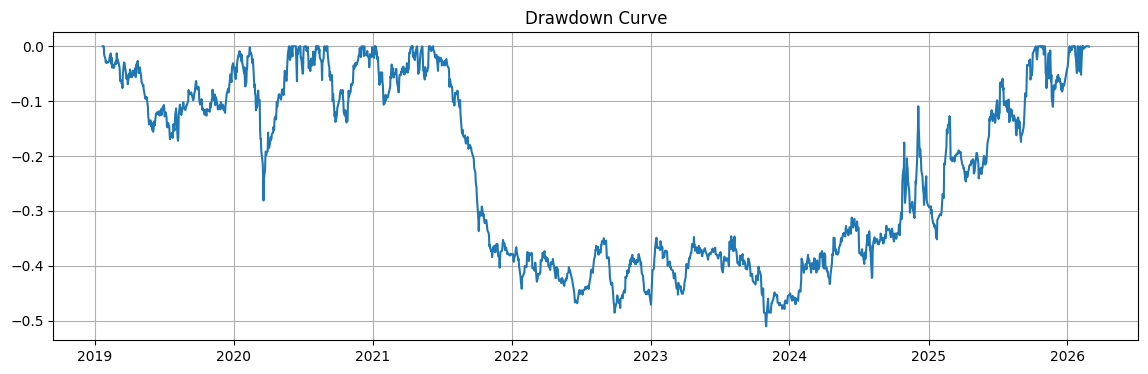

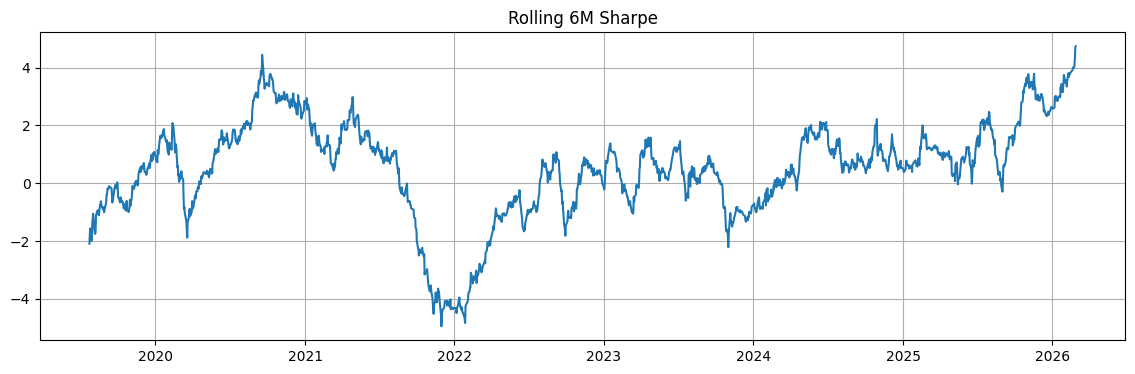

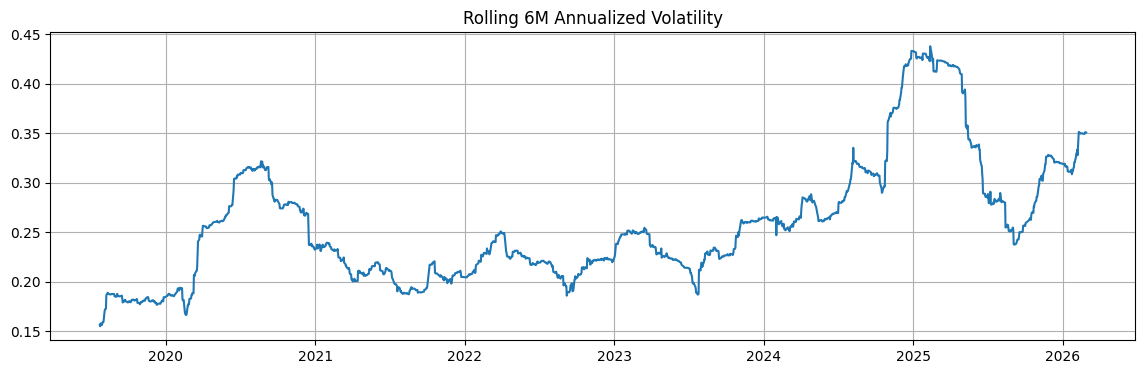

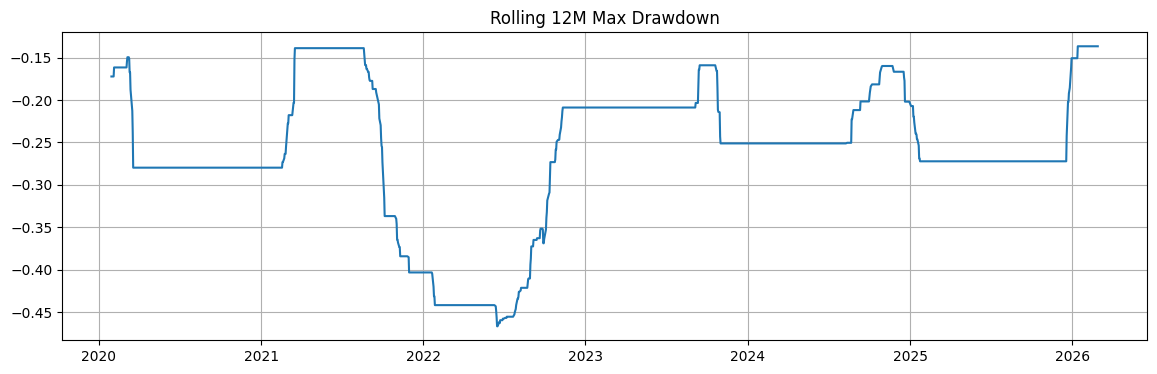

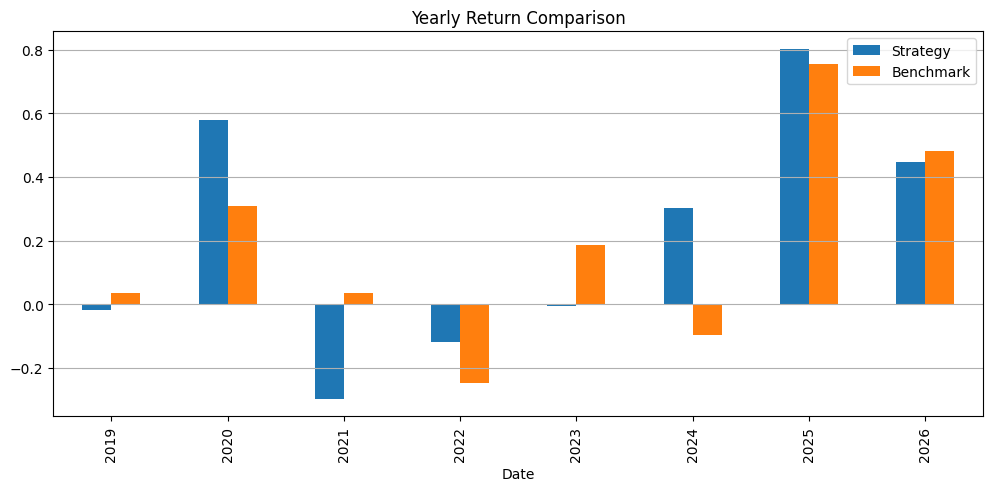

In [5]:
analysis_outputs = full_backtest_analysis(results, close_df)